In [1]:
import kagglehub

path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")

print("Path to dataset files:",path)

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/twitter-entity-sentiment-analysis


In [2]:
import os

# List the contents of the downloaded directory
print(os.listdir(path))

['twitter_validation.csv', 'twitter_training.csv']


In [3]:
import pandas as pd

# Construct the full path to the CSV file
csv_file_path = os.path.join(path, "twitter_training.csv") # Changed from Twitter_Data.csv

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [4]:
import shutil
import os

# Source directory (where kagglehub downloaded the files)
source_dir = path # 'path' variable already holds this value

# Destination directory (Colab local directory)
dest_dir = '.' # Current working directory

# Define the files to copy
files_to_copy = ['twitter_training.csv', 'twitter_validation.csv']

for filename in files_to_copy:
    source_file_path = os.path.join(source_dir, filename)
    destination_file_path = os.path.join(dest_dir, filename)
    shutil.copy(source_file_path, destination_file_path)
    print(f"Copied '{filename}' to '{destination_file_path}'")

print("Files in Colab local directory:")
print(os.listdir(dest_dir))

Copied 'twitter_training.csv' to './twitter_training.csv'
Copied 'twitter_validation.csv' to './twitter_validation.csv'
Files in Colab local directory:
['.config', 'twitter_validation.csv', 'twitter_training.csv', 'sample_data']


### 1. Data Loading and Initial Inspection

We'll load both the `twitter_training.csv` and `twitter_validation.csv` files. Based on the previous `df.head()` output (from `PcQQ7v9Lm8bG`), it appears the CSVs do not have a header row, so we'll load them without a header and then assign meaningful column names. We will also check the distribution of sentiment labels.

In [5]:
import pandas as pd
import numpy as np

# Define column names based on previous inspection
column_names = ['Tweet_ID', 'Entity', 'Sentiment', 'Tweet_Content']

# Load the training dataset
try:
    train_df = pd.read_csv('twitter_training.csv', header=None, names=column_names)
    print("Training data loaded successfully.")
except FileNotFoundError:
    print("Error: 'twitter_training.csv' not found. Please ensure it's in the current directory.")
    train_df = pd.DataFrame(columns=column_names)

# Load the validation dataset
try:
    val_df = pd.read_csv('twitter_validation.csv', header=None, names=column_names)
    print("Validation data loaded successfully.")
except FileNotFoundError:
    print("Error: 'twitter_validation.csv' not found. Please ensure it's in the current directory.")
    val_df = pd.DataFrame(columns=column_names)


if not train_df.empty:
    print("\n--- Training Data Info ---")
    train_df.info()
    display(train_df.head())
    print("\nSentiment distribution in training data:")
    display(train_df['Sentiment'].value_counts())

if not val_df.empty:
    print("\n--- Validation Data Info ---")
    val_df.info()
    display(val_df.head())
    print("\nSentiment distribution in validation data:")
    display(val_df['Sentiment'].value_counts())

Training data loaded successfully.
Validation data loaded successfully.

--- Training Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet_ID       74682 non-null  int64 
 1   Entity         74682 non-null  object
 2   Sentiment      74682 non-null  object
 3   Tweet_Content  73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


,Tweet_ID,Entity,Sentiment,Tweet_Content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...



Sentiment distribution in training data:


,count
Sentiment,
Negative,22542
Positive,20832
Neutral,18318
Irrelevant,12990



--- Validation Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Tweet_ID       1000 non-null   int64 
 1   Entity         1000 non-null   object
 2   Sentiment      1000 non-null   object
 3   Tweet_Content  1000 non-null   object
dtypes: int64(1), object(3)
memory usage: 31.4+ KB


,Tweet_ID,Entity,Sentiment,Tweet_Content
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...



Sentiment distribution in validation data:


,count
Sentiment,
Neutral,285
Positive,277
Negative,266
Irrelevant,172


It appears the 'Irrelevant' sentiment class is present in both datasets. Since the goal is to classify into 'negative', 'positive', or 'neutral', we will filter out the 'Irrelevant' tweets. We will also check for and handle any missing 'Tweet_Content' values.

In [6]:
# Filter out 'Irrelevant' sentiment from both training and validation sets
train_df = train_df[train_df['Sentiment'] != 'Irrelevant'].reset_index(drop=True)
val_df = val_df[val_df['Sentiment'] != 'Irrelevant'].reset_index(drop=True)

print("\nTraining data sentiment distribution after removing 'Irrelevant':")
display(train_df['Sentiment'].value_counts())

print("\nValidation data sentiment distribution after removing 'Irrelevant':")
display(val_df['Sentiment'].value_counts())

# Check for missing values in the text content after filtering
print("\nMissing values in training data (Tweet_Content):", train_df['Tweet_Content'].isnull().sum())
print("Missing values in validation data (Tweet_Content):", val_df['Tweet_Content'].isnull().sum())

# Drop rows where 'Tweet_Content' is missing (if any)
train_df.dropna(subset=['Tweet_Content'], inplace=True)
val_df.dropna(subset=['Tweet_Content'], inplace=True)

print("Missing values in training data (Tweet_Content) after dropping NaNs:", train_df['Tweet_Content'].isnull().sum())
print("Missing values in validation data (Tweet_Content) after dropping NaNs:", val_df['Tweet_Content'].isnull().sum())


Training data sentiment distribution after removing 'Irrelevant':


,count
Sentiment,
Negative,22542
Positive,20832
Neutral,18318



Validation data sentiment distribution after removing 'Irrelevant':


,count
Sentiment,
Neutral,285
Positive,277
Negative,266



Missing values in training data (Tweet_Content): 571
Missing values in validation data (Tweet_Content): 0
Missing values in training data (Tweet_Content) after dropping NaNs: 0
Missing values in validation data (Tweet_Content) after dropping NaNs: 0


### 2. Text Preprocessing and Vectorization

Before we can feed the text data into our machine learning models, we need to preprocess it. This involves several steps:
1.  **Cleaning the text:** Removing unwanted characters, converting to lowercase.
2.  **Vectorization:** Converting the cleaned text into numerical feature vectors. We will use `TF-IDF (Term Frequency-Inverse Document Frequency)` for this purpose, which reflects how important a word is to a document in a collection or corpus.

In [7]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Download necessary NLTK data (if not already downloaded)
# It's more robust to just download them directly at the beginning
# rather than relying on a LookupError during instantiation.
nltk.download('stopwords', quiet=True) # quiet=True to suppress output if already downloaded
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True) # Open Multilingual Wordnet is often a dependency for WordNetLemmatizer

# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer() # This should now succeed as resources are downloaded
stop_words = set(stopwords.words('english'))

# Define a text cleaning function
def clean_text(text):
    if not isinstance(text, str): # Ensure input is string
        return ""
    text = text.lower() # Convert to lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text) # Remove URLs
    text = re.sub(r'<.*?>', '', text) # Remove HTML tags
    # FIX: Corrected regex to keep spaces. Use r'[^a-z0-9\s]' or r'[^a-z0-9 ]'
    # The previous r'[^a-z0-9\\s]' was escaping the backslash, making \s literal.
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove special characters and punctuation, but keep spaces
    text = re.sub(r'\d+', '', text) # Remove numbers
    text = text.split() # Tokenize
    text = [lemmatizer.lemmatize(word) for word in text if word not in stop_words] # Lemmatize and remove stopwords
    text = ' '.join(text)
    return text

# Apply the cleaning function to the 'Tweet_Content' column
train_df['cleaned_text'] = train_df['Tweet_Content'].apply(clean_text)
val_df['cleaned_text'] = val_df['Tweet_Content'].apply(clean_text)

print("Original Tweet Content (Training Data):")
display(train_df[['Tweet_Content', 'cleaned_text']].head())

print("\nOriginal Tweet Content (Validation Data):")
display(val_df[['Tweet_Content', 'cleaned_text']].head())

Original Tweet Content (Training Data):


,Tweet_Content,cleaned_text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder



Original Tweet Content (Validation Data):


,Tweet_Content,cleaned_text
0,BBC News - Amazon boss Jeff Bezos rejects clai...,bbc news amazon bos jeff bezos reject claim co...
1,@Microsoft Why do I pay for WORD when it funct...,microsoft pay word function poorly samsungus c...
2,"CSGO matchmaking is so full of closet hacking,...",csgo matchmaking full closet hacking truly awf...
3,Now the President is slapping Americans in the...,president slapping american face really commit...
4,Hi @EAHelp I’ve had Madeleine McCann in my cel...,hi eahelp ive madeleine mccann cellar past yea...


In [8]:
# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 for efficiency

# Fit the vectorizer on the training data and transform both training and validation data
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['cleaned_text'])
X_val_tfidf = tfidf_vectorizer.transform(val_df['cleaned_text'])

# Get target variables
y_train = train_df['Sentiment']
y_val = val_df['Sentiment']

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_val_tfidf: {X_val_tfidf.shape}")
print("\nFirst 5 TF-IDF features for training data:")
display(pd.DataFrame(X_train_tfidf[:5].toarray(), columns=tfidf_vectorizer.get_feature_names_out()))

Shape of X_train_tfidf: (61121, 5000)
Shape of X_val_tfidf: (828, 5000)

First 5 TF-IDF features for training data:


,aaa,aaron,ab,abandon,abandoned,ability,able,absolute,absolutely,absurd,...,zelda,zer,zero,zip,zoe,zombie,zone,zonestreamcx,zoom,zuckerberg
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 3. Model Training and Evaluation

Now we will train two classification models: Logistic Regression and Support Vector Machine (SVM). For each model, we will:
1.  Train the model on the `X_train_tfidf` and `y_train` data.
2.  Make predictions on the `X_val_tfidf` data.
3.  Evaluate the model's performance using classification reports and confusion matrices.

#### 3.1 Logistic Regression Model

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.89      0.85       266
     Neutral       0.89      0.78      0.83       285
    Positive       0.86      0.89      0.88       277

    accuracy                           0.85       828
   macro avg       0.85      0.85      0.85       828
weighted avg       0.86      0.85      0.85       828



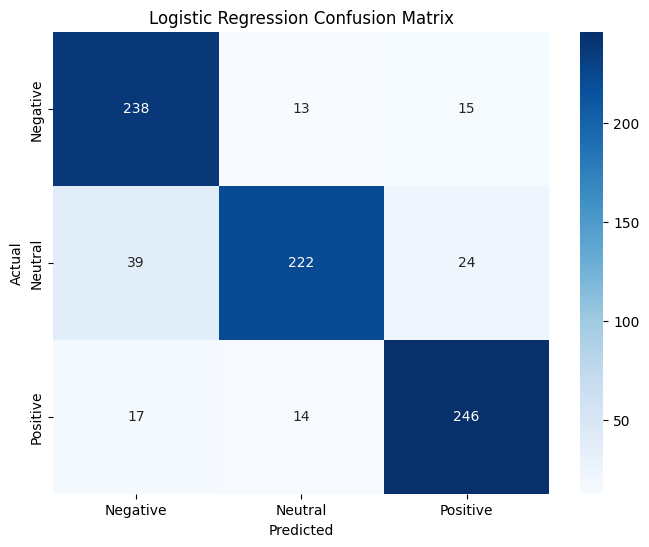

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train_tfidf, y_train)

# Make predictions on the validation set
y_pred_log_reg = log_reg_model.predict(X_val_tfidf)

# Evaluate the model
print("Logistic Regression Classification Report:")
print(classification_report(y_val, y_pred_log_reg))

# Plot Confusion Matrix
cm_log_reg = confusion_matrix(y_val, y_pred_log_reg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues',
            xticklabels=log_reg_model.classes_, yticklabels=log_reg_model.classes_)
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [10]:
# Make predictions on the training set for Logistic Regression
y_pred_log_reg_train = log_reg_model.predict(X_train_tfidf)

# Evaluate the model on the training set
print("Logistic Regression Training Classification Report:")
print(classification_report(y_train, y_pred_log_reg_train))

Logistic Regression Training Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.84      0.84     22358
     Neutral       0.76      0.76      0.76     18108
    Positive       0.82      0.80      0.81     20655

    accuracy                           0.80     61121
   macro avg       0.80      0.80      0.80     61121
weighted avg       0.80      0.80      0.80     61121



#### 3.2 Support Vector Machine (SVM) Model

In [ ]:
from sklearn.svm import SVC

# Initialize and train SVM model
# Using a linear kernel for text classification is often efficient and effective
# Setting probability=True can be useful if you need probability estimates, but can add to training time
svm_model = SVC(kernel='linear', random_state=42, probability=True)
svm_model.fit(X_train_tfidf, y_train)

# Make predictions on the validation set
y_pred_svm = svm_model.predict(X_val_tfidf)

# Evaluate the model
print("SVM Classification Report:")
print(classification_report(y_val, y_pred_svm))

# Plot Confusion Matrix
cm_svm = confusion_matrix(y_val, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=svm_model.classes_, yticklabels=svm_model.classes_)
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 4. Predict Sentiment for a New Sentence

Now, let's use our trained models to predict the sentiment of a new, user-provided sentence. We'll apply the same preprocessing steps (cleaning and TF-IDF vectorization) to the new sentence as we did for our training data.

In [15]:
new_sentence = input("Enter a sentence to predict its sentiment: ")

# Preprocess the new sentence
cleaned_new_sentence = clean_text(new_sentence)

# Transform the cleaned sentence using the fitted TF-IDF vectorizer
X_new_tfidf = tfidf_vectorizer.transform([cleaned_new_sentence])

# Predict with Logistic Regression model
log_reg_prediction = log_reg_model.predict(X_new_tfidf)[0]

print(f"\nOriginal Sentence: {new_sentence}")
print(f"Cleaned Sentence: {cleaned_new_sentence}")
print(f"Logistic Regression Prediction: {log_reg_prediction}")

Enter a sentence to predict its sentiment: The weather today is neither good nor bad, just cloudy.

Original Sentence: The weather today is neither good nor bad, just cloudy.
Cleaned Sentence: weather today neither good bad cloudy
Logistic Regression Prediction: Positive


Here are some sample sentences you can use to test the sentiment prediction:

*   "I absolutely love this product! It's fantastic and works perfectly."
*   "This movie was a complete waste of time. I'm so disappointed."
*   "The weather today is neither good nor bad, just cloudy."
*   "I'm feeling really happy and optimistic about the future."
*   "The customer service was terrible, I had a very negative experience."